# Capstone Project Model 3: Customer Rating Prediction team 89

**Students:** Ziad Salah , Ziad tamer , Rana Ali , Rawan Samir , Shahd Abdallah

**Track:** Data Science Machine Learning

**Chosen Model:** Model 3 — Rating Prediction (Regression)

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [95]:
import joblib

In [2]:
pd.set_option('display.max_columns', 50)

## Load Data



In [6]:
orders = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_orders_dataset.csv')
customers = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_customers_dataset.csv')
items = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_order_items_dataset.csv')
products = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_products_dataset.csv')
payments = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_order_payments_dataset.csv')
reviews = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/olist_sellers_dataset.csv')
cat_translation = pd.read_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/raw/product_category_name_translation.csv')

orders_raw = orders.copy()

In [7]:
print('orders:', orders.shape)
print('customers:', customers.shape)
print('items:', items.shape)
print('products:', products.shape)
print('payments:', payments.shape)
print('reviews:', reviews.shape)
print('sellers:', sellers.shape)
print('cat_translation:', cat_translation.shape)

orders: (99441, 8)
customers: (99441, 5)
items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)
sellers: (3095, 4)
cat_translation: (73, 2)


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
orders.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


## Data Audit


In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [14]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [ ]:
missing = pd.DataFrame({'count': orders.isna().sum(), 'percent': orders.isna().mean().multiplytiplytiplytiply(100).round(2)}).sort_values('percent', ascending=False)


In [103]:
print(missing)

                               count  percent
order_delivered_customer_date   2965     2.98
order_delivered_carrier_date    1783     1.79
order_approved_at                160     0.16
order_id                           0     0.00
order_purchase_timestamp           0     0.00
order_status                       0     0.00
customer_id                        0     0.00
order_estimated_delivery_date      0     0.00


In [21]:
print('duplicate rows:', orders.duplicated().sum())
print('duplicate order_id:', orders.duplicated('order_id').sum())

duplicate rows: 0
duplicate order_id: 0


In [28]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [31]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [29]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [35]:
null_tokens = ['NA', 'N/A', 'Null', 'null', 'NaN', '-', '', ' ']

for i in orders.select_dtypes(include='object').columns:
    
    hits = orders[i].isin(null_tokens).sum()
    if hits > 0:
        print(i, hits)

print('done checking nulls')
print('found null values in objects: ', hits)

done checking nulls
found null values in objects:  0


In [37]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [104]:
print(reviews['review_score'].value_counts(normalize=True).sort_index().multiply(100).round(2))

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64


In [44]:
print(reviews.isna().sum())
print('duplicate order_id in reviews :', reviews.duplicated('order_id').sum())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
duplicate order_id in reviews : 551


## Preprocessing

In [47]:
dates_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date','order_delivered_customer_date', 'order_estimated_delivery_date']

for i in dates_cols:
    orders[i] = pd.to_datetime(orders[i])

print('date range:', orders['order_purchase_timestamp'].min(), 'to', orders['order_purchase_timestamp'].max())

date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [50]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [52]:
products_category = products.merge(cat_translation, on='product_category_name', how='left')
products_category['product_category_name_english'] = products_category['product_category_name_english'].fillna('unknown')

items_full = items.merge(products_category[['product_id', 'product_category_name_english']], on='product_id', how='left')
items_full = items_full.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
items_full.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,PR


In [53]:
def most_common(series):
    return series.mode().iloc[0] if not series.mode().empty else 'unknown'

items_agg = items_full.groupby('order_id').agg(
    n_items=('order_item_id', 'count'),
    n_distinct_products=('product_id', 'nunique'),
    n_distinct_sellers=('seller_id', 'nunique'),
    total_price=('price', 'sum'),
    avg_item_price=('price', 'mean'),
    total_freight=('freight_value', 'sum'),
).reset_index()

dominant_category = items_full.groupby('order_id')['product_category_name_english'].agg(most_common).reset_index()
dominant_category.columns = ['order_id', 'product_category']

dominant_seller_state = items_full.groupby('order_id')['seller_state'].agg(most_common).reset_index()
dominant_seller_state.columns = ['order_id', 'seller_state']

items_agg = items_agg.merge(dominant_category, on='order_id', how='left')
items_agg = items_agg.merge(dominant_seller_state, on='order_id', how='left')
items_agg.head()

,order_id,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,58.90,13.29,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,239.90,19.93,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,199.00,17.87,furniture_decor,MG
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.99,12.79,perfumery,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,199.90,18.14,garden_tools,PR


In [54]:
## one row per order: payment totals
payments_agg = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    n_payment_methods=('payment_type', 'nunique'),
).reset_index()

dominant_payment = payments.groupby('order_id')['payment_type'].agg(most_common).reset_index()
dominant_payment.columns = ['order_id', 'payment_type']
payments_agg = payments_agg.merge(dominant_payment, on='order_id', how='left')
payments_agg.head()

,order_id,total_payment_value,max_installments,n_payment_methods,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [55]:
## reviews: keep only the most recent review per order (target = review_score)
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])
reviews_dedup = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')
reviews_clean = reviews_dedup[['order_id', 'review_score']].copy()
print('reviews after dedup:', reviews_clean.shape)

reviews after dedup: (98673, 2)


In [56]:
## master merge: one row per order
df = orders.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')
df = df.merge(payments_agg, on='order_id', how='left')
df = df.merge(reviews_clean, on='order_id', how='left')

print('merged shape:', df.shape)
df.head()

merged shape: (99441, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,seller_state,total_payment_value,max_installments,n_payment_methods,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,1.0,1.0,1.0,29.99,29.99,8.72,housewares,SP,38.71,1.0,2.0,voucher,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,1.0,1.0,1.0,118.70,118.70,22.76,perfumery,SP,141.46,1.0,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,1.0,1.0,1.0,159.90,159.90,19.22,auto,SP,179.12,3.0,1.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,1.0,1.0,1.0,45.00,45.00,27.20,pet_shop,MG,72.20,1.0,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,1.0,1.0,1.0,19.90,19.90,8.72,stationery,SP,28.62,1.0,1.0,credit_card,5.0


In [57]:
before = len(df)
df = df.dropna(subset=['review_score']).copy()
print(f'dropped {before - len(df)} rows with no review (missing target)')

before = len(df)
df = df.dropna(subset=['n_items']).copy()
print(f'dropped {before - len(df)} rows with no matching order items')

before = len(df)
df = df.dropna(subset=['order_delivered_customer_date']).copy()
print(f'dropped {before - len(df)} rows with missing delivery date')

df['seller_state'] = df['seller_state'].fillna('unknown')

before = len(df)
df = df.dropna(subset=['total_payment_value']).copy()
print(f'dropped {before - len(df)} row(s) with no matching payment record')

df['review_score'] = df['review_score'].astype(int)
print('\nfinal cleaned shape:', df.shape)

dropped 768 rows with no review (missing target)
dropped 756 rows with no matching order items
dropped 2087 rows with missing delivery date
dropped 1 row(s) with no matching payment record

final cleaned shape: (95829, 22)


In [58]:
## business rule validation
print('orders with total_price <= 0:', (df['total_price'] <= 0).sum())
print('orders with review_score outside 1-5:', (~df['review_score'].between(1, 5)).sum())
print('orders with n_items <= 0:', (df['n_items'] <= 0).sum())
print('exact duplicate rows:', df.duplicated().sum())
print('duplicate order_id:', df.duplicated('order_id').sum())
print('\norder_status after cleaning:')
print(df['order_status'].value_counts())

orders with total_price <= 0: 0
orders with review_score outside 1-5: 0
orders with n_items <= 0: 0
exact duplicate rows: 0
duplicate order_id: 0

order_status after cleaning:
order_status
delivered    95823
canceled         6
Name: count, dtype: int64


## Feature Engineering

In [59]:
## delivery timing
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = (df['delivery_delay_days'] > 0).astype(int)

df['approval_time_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
df['approval_time_hours'] = df['approval_time_hours'].fillna(df['approval_time_hours'].median())

print('overall late-delivery rate:', df['is_late'].mean().round(4))

overall late-delivery rate: 0.0666


In [60]:
## calendar features
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_weekday'] = df['order_purchase_timestamp'].dt.dayofweek
df['order_hour'] = df['order_purchase_timestamp'].dt.hour
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)

## Brazil is in the Southern Hemisphere, so seasons are shifted vs the Northern Hemisphere
season_map = {12: 'Summer', 1: 'Summer', 2: 'Summer',
              3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
              6: 'Winter', 7: 'Winter', 8: 'Winter',
              9: 'Spring', 10: 'Spring', 11: 'Spring'}
df['season'] = df['order_month'].map(season_map)
df[['order_month', 'season']].drop_duplicates().sort_values('order_month')

,order_month,season
8,1,Summer
4,2,Summer
14,3,Autumn
31,4,Autumn
7,5,Autumn
12,6,Winter
1,7,Winter
2,8,Winter
20,9,Spring
0,10,Spring


In [ ]:
## logistics features
df['same_state_delivery'] = (df['customer_state'] == df['seller_state']).astype(int)
df['freight_ratio'] = df['total_freight'] / df['total_price']

## SImultiplyATED competitor price (Olist has no real competitor pricing data)
noise = np.random.normal(loc=0.0, scale=0.08, size=len(df))
df['competitor_price'] = (df['total_price'] * (1 + noise)).clip(lower=1)
df['price_gap'] = df['total_price'] - df['competitor_price']
df['is_pricier'] = (df['price_gap'] > 0).astype(int)

df[['delivery_delay_days', 'is_late', 'season', 'freight_ratio', 'price_gap']].head()

,delivery_delay_days,is_late,season,freight_ratio,price_gap
0,-8,0,Spring,0.290764,-1.305953
1,-6,0,Winter,0.191744,-9.710014
2,-18,0,Winter,0.120200,-17.457476
3,-13,0,Spring,0.604444,-6.569423
4,-10,0,Summer,0.438191,-1.051096


In [62]:
## drop IDs, raw timestamps (already extracted), and the near-constant order_status
drop_cols = ['order_id', 'customer_id',
             'order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date',
             'order_status']
df_model = df.drop(columns=drop_cols)
print('feature set shape:', df_model.shape)
df_model.columns.tolist()

feature set shape: (95829, 27)


['customer_state',
 'n_items',
 'n_distinct_products',
 'n_distinct_sellers',
 'total_price',
 'avg_item_price',
 'total_freight',
 'product_category',
 'seller_state',
 'total_payment_value',
 'max_installments',
 'n_payment_methods',
 'payment_type',
 'review_score',
 'delivery_delay_days',
 'is_late',
 'approval_time_hours',
 'order_month',
 'order_weekday',
 'order_hour',
 'is_weekend',
 'season',
 'same_state_delivery',
 'freight_ratio',
 'competitor_price',
 'price_gap',
 'is_pricier']

## Explore Data Analysis

In [63]:
print(df_model.shape)
df_model.describe(include='all').T

(95829, 27)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_state,95829,27,SP,40266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_items,95829.0,NaN,NaN,NaN,1.141262,0.534067,1.0,1.0,1.0,1.0,21.0
n_distinct_products,95829.0,NaN,NaN,NaN,1.038318,0.227215,1.0,1.0,1.0,1.0,8.0
n_distinct_sellers,95829.0,NaN,NaN,NaN,1.013848,0.123375,1.0,1.0,1.0,1.0,5.0
total_price,95829.0,NaN,NaN,NaN,136.798419,207.783858,0.85,45.9,86.25,149.9,13440.0
avg_item_price,95829.0,NaN,NaN,NaN,125.04126,188.298319,0.85,41.9,79.0,139.9,6735.0
total_freight,95829.0,NaN,NaN,NaN,22.762669,21.522163,0.0,13.84,17.16,23.99,1794.96
product_category,95829,74,bed_bath_table,9144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,95829,22,SP,67802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_payment_value,95829.0,NaN,NaN,NaN,159.590528,217.507603,9.59,61.84,105.28,176.16,13664.08


In [64]:
num_cols_check = df_model.select_dtypes(include='number').columns
for col in num_cols_check:
    print(f"{col}: min={df_model[col].min():.2f}  max={df_model[col].max():.2f}")

n_items: min=1.00  max=21.00
n_distinct_products: min=1.00  max=8.00
n_distinct_sellers: min=1.00  max=5.00
total_price: min=0.85  max=13440.00
avg_item_price: min=0.85  max=6735.00
total_freight: min=0.00  max=1794.96
total_payment_value: min=9.59  max=13664.08
max_installments: min=0.00  max=24.00
n_payment_methods: min=1.00  max=2.00
review_score: min=1.00  max=5.00
delivery_delay_days: min=-147.00  max=188.00
is_late: min=0.00  max=1.00
approval_time_hours: min=0.00  max=741.44
order_month: min=1.00  max=12.00
order_weekday: min=0.00  max=6.00
order_hour: min=0.00  max=23.00
is_weekend: min=0.00  max=1.00
same_state_delivery: min=0.00  max=1.00
freight_ratio: min=0.00  max=21.45
competitor_price: min=1.00  max=12746.70
price_gap: min=-580.03  max=881.02
is_pricier: min=0.00  max=1.00


### Target distribution

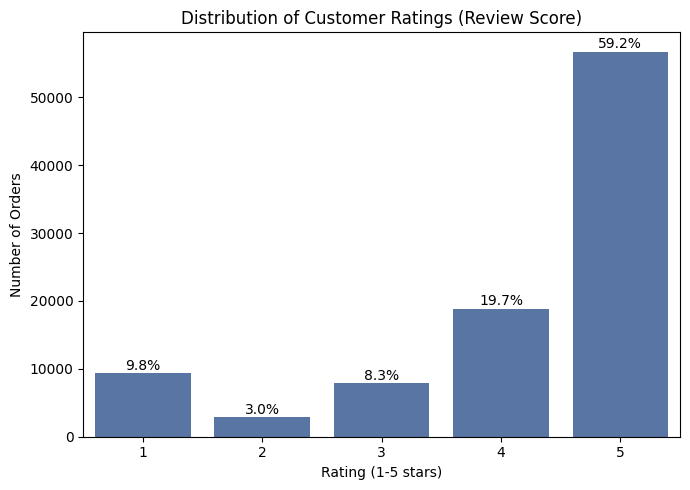

review_score
1     9.761137
2     3.048138
3     8.261591
4    19.710109
5    59.219026
Name: count, dtype: float64
mean: 4.156   skew: -1.483


In [67]:
order_labels = [1, 2, 3, 4, 5]
counts = df_model['review_score'].value_counts().reindex(order_labels).fillna(0).astype(int)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=counts.index, y=counts.values, color='#4C72B0')
plt.title('Distribution of Customer Ratings (Review Score)')
plt.xlabel('Rating (1-5 stars)')
plt.ylabel('Number of Orders')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v/counts.sum()*100:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\01_target_distribution.png')
plt.show()

print(counts / counts.sum() * 100)
print('mean:', df_model['review_score'].mean().round(3), '  skew:', df_model['review_score'].skew().round(3))

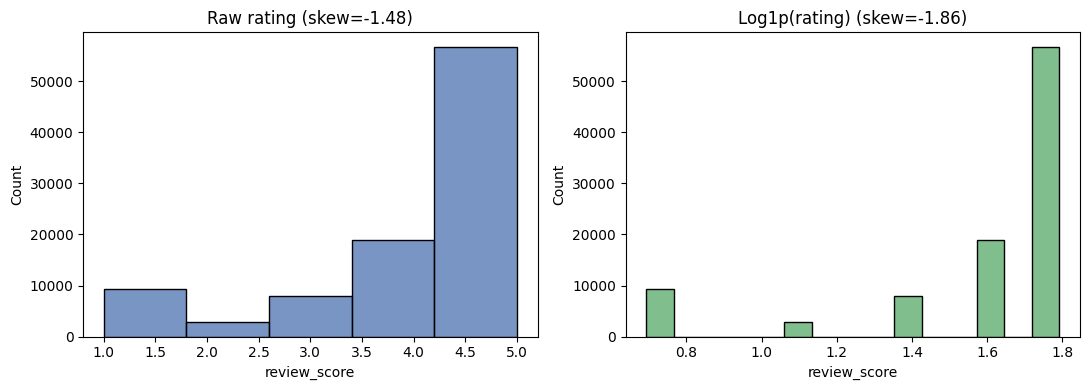

In [68]:
log_score = np.log1p(df_model['review_score'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_model['review_score'], bins=5, ax=axes[0], color='#4C72B0')
axes[0].set_title(f"Raw rating (skew={df_model['review_score'].skew():.2f})")
sns.histplot(log_score, bins=15, ax=axes[1], color='#55A868')
axes[1].set_title(f'Log1p(rating) (skew={log_score.skew():.2f})')
plt.tight_layout()
plt.show()

### Feature vs target relationships

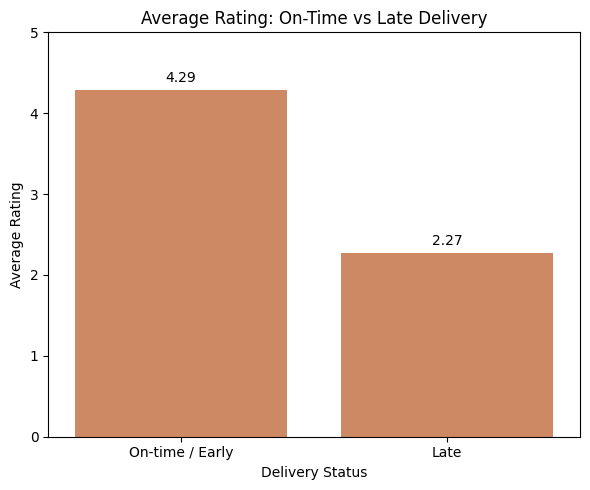

is_late
0    4.290247
1    2.270804
Name: review_score, dtype: float64


In [70]:
late_means = df_model.groupby('is_late')['review_score'].mean()

plt.figure(figsize=(6, 5))
ax = sns.barplot(x=['On-time / Early', 'Late'], y=late_means.values, color='#DD8452')
plt.title('Average Rating: On-Time vs Late Delivery')
plt.xlabel('Delivery Status')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
for i, v in enumerate(late_means.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\02_rating_by_late_delivery.png')
plt.show()

print(late_means)

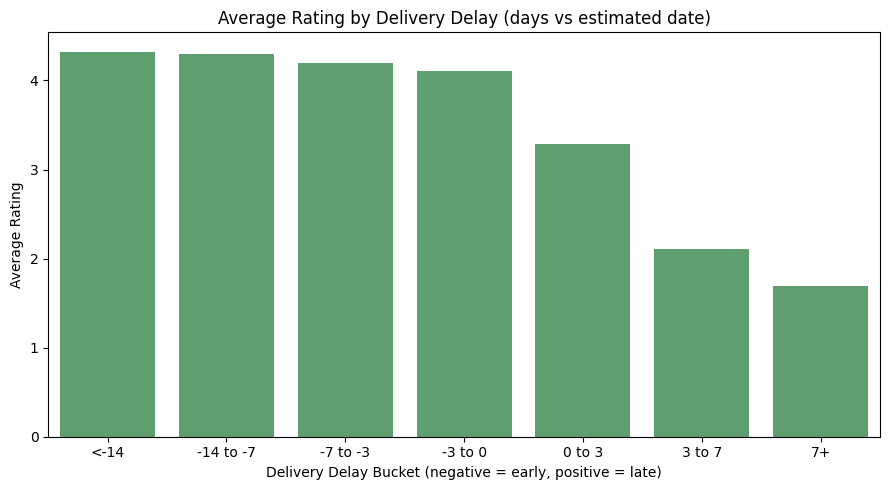

delay_bucket
<-14         4.323891
-14 to -7    4.299118
-7 to -3     4.191431
-3 to 0      4.108197
0 to 3       3.291037
3 to 7       2.102975
7+           1.696872
Name: review_score, dtype: float64


In [71]:
bins = [-999, -14, -7, -3, 0, 3, 7, 999]
labels = ['<-14', '-14 to -7', '-7 to -3', '-3 to 0', '0 to 3', '3 to 7', '7+']
df_model['delay_bucket'] = pd.cut(df_model['delivery_delay_days'], bins=bins, labels=labels)
bucket_means = df_model.groupby('delay_bucket', observed=True)['review_score'].mean()

plt.figure(figsize=(9, 5))
sns.barplot(x=bucket_means.index, y=bucket_means.values, color='#55A868')
plt.title('Average Rating by Delivery Delay (days vs estimated date)')
plt.xlabel('Delivery Delay Bucket (negative = early, positive = late)')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\03_rating_by_delay_bucket.png')
plt.show()

print(bucket_means)

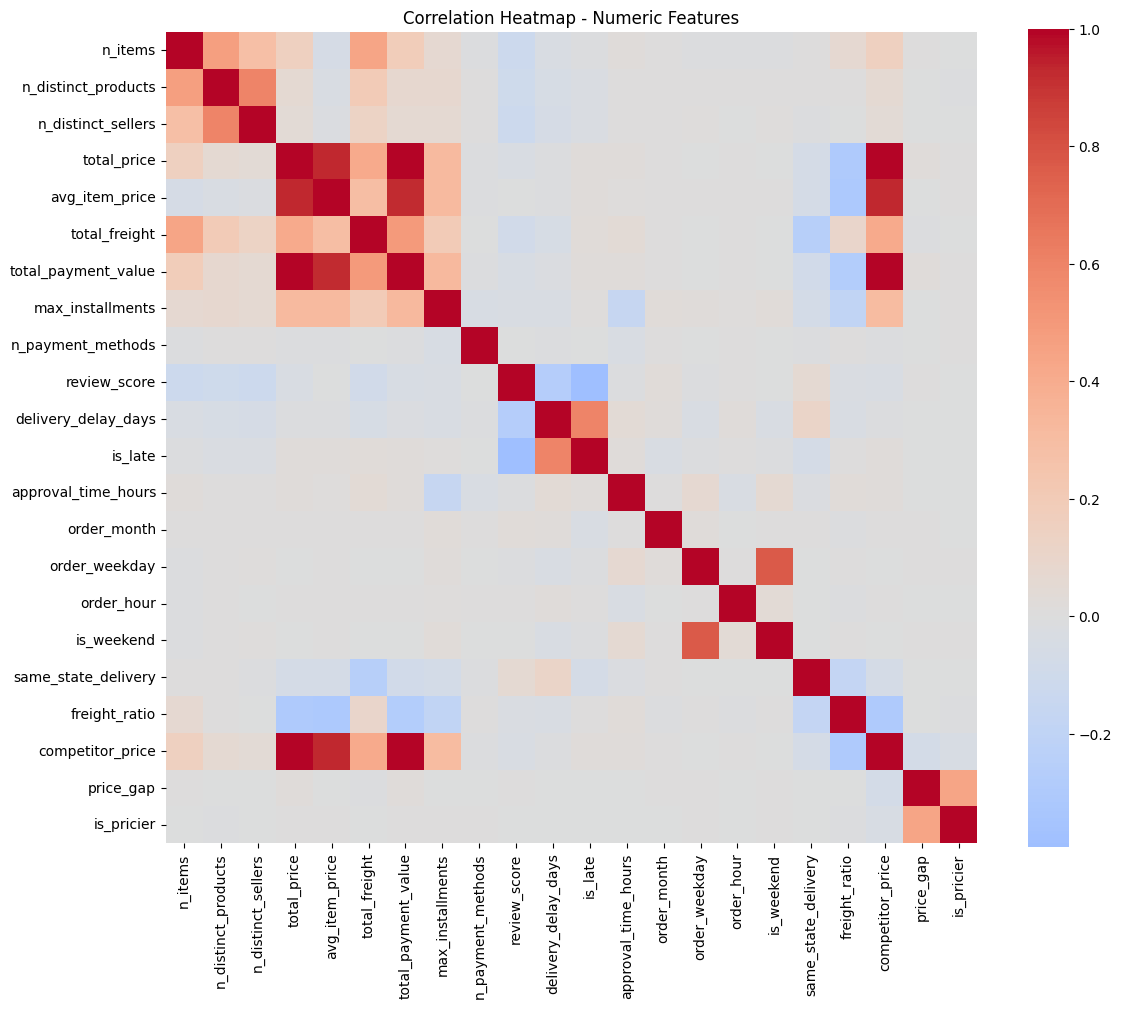

is_late               -0.391828
delivery_delay_days   -0.267029
n_items               -0.122975
n_distinct_sellers    -0.116365
n_distinct_products   -0.105230
total_freight         -0.089604
total_payment_value   -0.041763
total_price           -0.034406
competitor_price      -0.034373
max_installments      -0.031007
freight_ratio         -0.023826
approval_time_hours   -0.015945
order_weekday         -0.009688
avg_item_price        -0.004956
is_weekend            -0.002017
n_payment_methods     -0.001982
is_pricier            -0.001076
price_gap              0.000519
order_hour             0.004424
order_month            0.031040
same_state_delivery    0.063328
review_score           1.000000
Name: review_score, dtype: float64


In [72]:
num_cols = df_model.select_dtypes(include='number').columns
corr = df_model[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\04_correlation_heatmap.png')
plt.show()

print(corr['review_score'].sort_values())

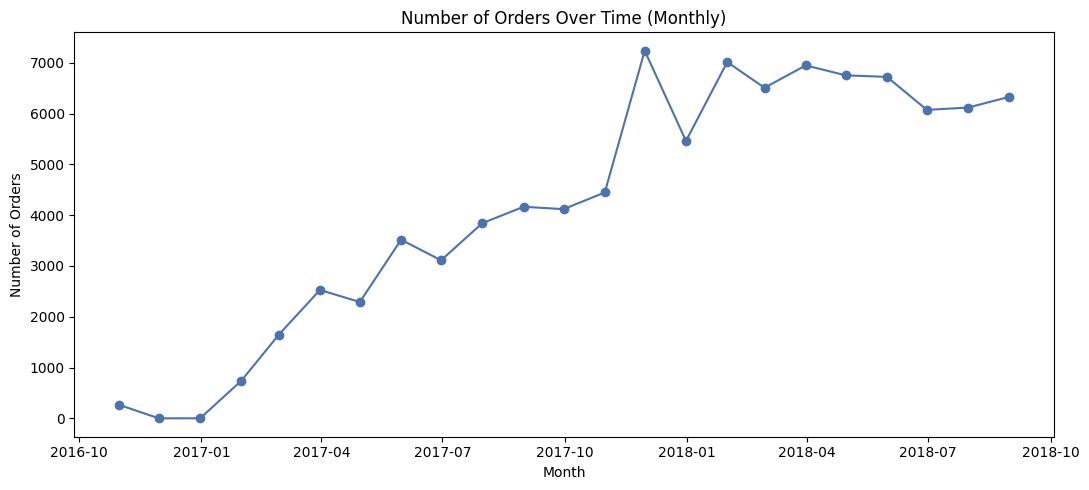

In [73]:
monthly = df.set_index('order_purchase_timestamp').resample('ME').size()

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='#4C72B0')
plt.title('Number of Orders Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\05_orders_over_time.png')
plt.show()

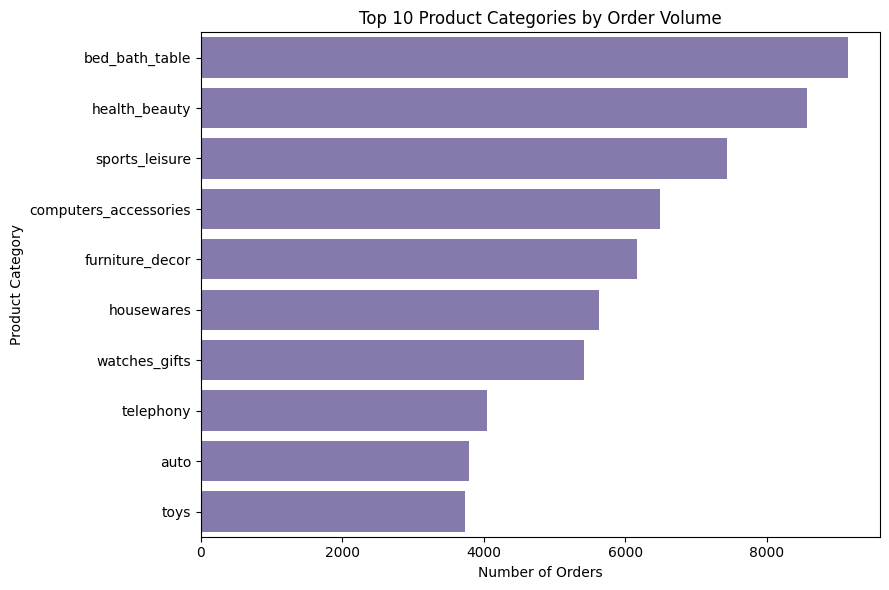

product_category
bed_bath_table           4.002843
telephony                4.058068
furniture_decor          4.072704
computers_accessories    4.082614
watches_gifts            4.129134
auto                     4.146367
housewares               4.206529
health_beauty            4.232393
sports_leisure           4.237423
toys                     4.246447
Name: review_score, dtype: float64


In [74]:
top_cats = df_model['product_category'].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(y=top_cats.index, x=top_cats.values, color='#8172B3', orient='h')
plt.title('Top 10 Product Categories by Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\06_top_categories.png')
plt.show()

cat_rating = df_model[df_model['product_category'].isin(top_cats.index)].groupby('product_category')['review_score'].mean().sort_values()
print(cat_rating)

## Train/Test Split



In [75]:
df_model = df_model.drop(columns=['delay_bucket'])

y = df_model['review_score']
X = df_model.drop(columns=['review_score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (76663, 26)  X_test: (19166, 26)


### Encoding & Scaling



In [76]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print('categorical columns:', cat_cols)
print('cardinality:', {c: X_train[c].nunique() for c in cat_cols})

categorical columns: ['customer_state', 'product_category', 'seller_state', 'payment_type', 'season']
cardinality: {'customer_state': 27, 'product_category': 74, 'seller_state': 22, 'payment_type': 4, 'season': 4}


In [77]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
label_encoders = {}
onehot_cols = []

for col in cat_cols:
    if X_train[col].nunique() > 50:
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train[col].astype(str))
        known = set(le.classes_)
        test_vals = X_test[col].astype(str).apply(lambda v: v if v in known else le.classes_[0])
        X_test_enc[col] = le.transform(test_vals)
        label_encoders[col] = le
    else:
        onehot_cols.append(col)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[onehot_cols])
train_ohe = pd.DataFrame(ohe.transform(X_train[onehot_cols]), columns=ohe.get_feature_names_out(onehot_cols), index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[onehot_cols]), columns=ohe.get_feature_names_out(onehot_cols), index=X_test.index)

X_train_enc = X_train_enc.drop(columns=onehot_cols).join(train_ohe)
X_test_enc = X_test_enc.drop(columns=onehot_cols).join(test_ohe)

print('encoded shape - train:', X_train_enc.shape, ' test:', X_test_enc.shape)

encoded shape - train: (76663, 79)  test: (19166, 79)


In [78]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns, index=X_train_enc.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns, index=X_test_enc.index)
X_train_scaled.head()

,n_items,n_distinct_products,n_distinct_sellers,total_price,avg_item_price,total_freight,product_category,total_payment_value,max_installments,n_payment_methods,delivery_delay_days,is_late,approval_time_hours,order_month,order_weekday,order_hour,is_weekend,same_state_delivery,freight_ratio,competitor_price,price_gap,is_pricier,customer_state_AC,customer_state_AL,customer_state_AM,...,seller_state_GO,seller_state_MA,seller_state_MG,seller_state_MS,seller_state_MT,seller_state_PA,seller_state_PB,seller_state_PE,seller_state_PI,seller_state_PR,seller_state_RJ,seller_state_RN,seller_state_RO,seller_state_RS,seller_state_SC,seller_state_SE,seller_state_SP,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,season_Autumn,season_Spring,season_Summer,season_Winter
45933,-0.265781,-0.168893,-0.11305,0.260501,0.351558,-0.307252,-1.534411,0.218374,-0.710705,6.523689,-0.205056,-0.267741,-0.487498,1.536397,0.121964,0.981878,-0.545801,-0.749243,-0.731276,0.410612,-1.588462,-1.006688,-0.02845,-0.063925,-0.039096,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,2.225954,-0.535224,-0.670760
24857,-0.265781,-0.168893,-0.11305,-0.417695,-0.400624,-0.237206,0.074595,-0.422827,-0.710705,-0.153287,-0.008327,-0.267741,-0.455528,-1.252480,-0.386969,0.418012,-0.545801,-0.749243,0.145258,-0.394016,-0.244492,-1.006688,-0.02845,-0.063925,-0.039096,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,1.868377,-0.670760
56536,-0.265781,-0.168893,-0.11305,-0.417262,-0.400144,-0.197776,1.260179,-0.418506,-0.710705,-0.153287,-2.369076,-0.267741,-0.489161,-0.012979,0.630897,-0.145855,-0.545801,-0.749243,0.198710,-0.409429,-0.077184,-1.006688,-0.02845,-0.063925,-0.039096,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,-0.535224,1.490847
66478,-0.265781,-0.168893,-0.11305,-0.272965,-0.240106,0.356559,0.709730,-0.225672,-0.341992,-0.153287,0.385131,-0.267741,-0.487242,-1.562355,-0.895903,-0.145855,-0.545801,-0.749243,0.234545,-0.273159,0.005667,0.993357,-0.02845,-0.063925,-0.039096,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,1.868377,-0.670760
71266,-0.265781,-0.168893,-0.11305,-0.513412,-0.506784,-0.649130,-1.068646,-0.555122,-0.710705,-0.153287,2.254057,3.734954,-0.492973,-1.252480,0.630897,0.981878,-0.545801,1.334681,-0.057331,-0.489038,-0.250564,-1.006688,-0.02845,-0.063925,-0.039096,...,-0.069261,-0.06194,-0.294072,-0.021372,-0.0365,-0.008847,-0.020435,-0.064743,-0.009556,-0.290391,-0.214029,-0.022848,-0.011422,-0.143698,-0.194736,-0.010216,0.642701,-0.49701,0.550792,-0.124383,-0.140787,-0.653233,-0.449246,1.868377,-0.670760


## Model Training — Compare 4 Algorithms



In [79]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=1),
    'KNN': KNeighborsRegressor()
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Tuned': 'No'})
    fitted_models[name] = model
    print(f'{name}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

LinearRegression: MAE=0.8887  RMSE=1.1453  R2=0.1909
DecisionTree: MAE=1.0684  RMSE=1.6448  R2=-0.6687
RandomForest: MAE=0.8946  RMSE=1.1460  R2=0.1899
KNN: MAE=0.9168  RMSE=1.2494  R2=0.0372


,Model,MAE,RMSE,R2,Tuned
0,LinearRegression,0.888651,1.145274,0.190949,No
1,RandomForest,0.894554,1.145987,0.189942,No
2,KNN,0.916832,1.249377,0.037182,No
3,DecisionTree,1.068350,1.644783,-0.668684,No


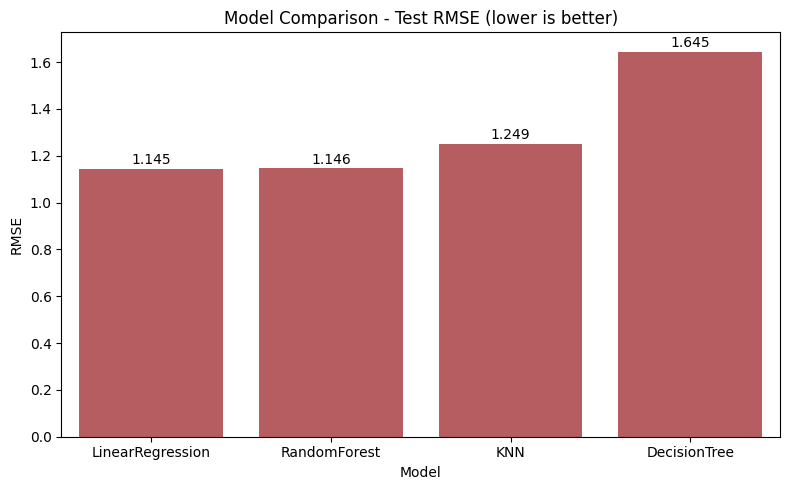

In [81]:
plt.figure(figsize=(8, 5))
comp = results_df.sort_values('RMSE')
ax = sns.barplot(x='Model', y='RMSE', data=comp, color='#C44E52')
plt.title('Model Comparison - Test RMSE (lower is better)')
plt.ylabel('RMSE')
for i, v in enumerate(comp['RMSE']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\07_model_comparison.png')
plt.show()

## Hyperparameter Tuning

In [82]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train_scaled.index, size=15000, replace=False)
X_tune = X_train_scaled.loc[sample_idx]
y_tune = y_train.loc[sample_idx]

param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=1
)
grid.fit(X_tune, y_tune)

print('Best params:', grid.best_params_)
print('Best CV RMSE:', -grid.best_score_)

Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV RMSE: 1.158159280355534


In [83]:
best_model = RandomForestRegressor(random_state=42, n_jobs=1, **grid.best_params_)
best_model.fit(X_train_scaled, y_train)

preds = best_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f'Tuned Random Forest on TEST set: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'RandomForest (tuned)', 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Tuned': 'Yes'
}])], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
results_df

Tuned Random Forest on TEST set: MAE=0.8734  RMSE=1.1297  R2=0.2128


,Model,MAE,RMSE,R2,Tuned
0,RandomForest (tuned),0.873411,1.129671,0.212845,Yes
1,LinearRegression,0.888651,1.145274,0.190949,No
2,RandomForest,0.894554,1.145987,0.189942,No
3,KNN,0.916832,1.249377,0.037182,No
4,DecisionTree,1.068350,1.644783,-0.668684,No


## Final Evaluation

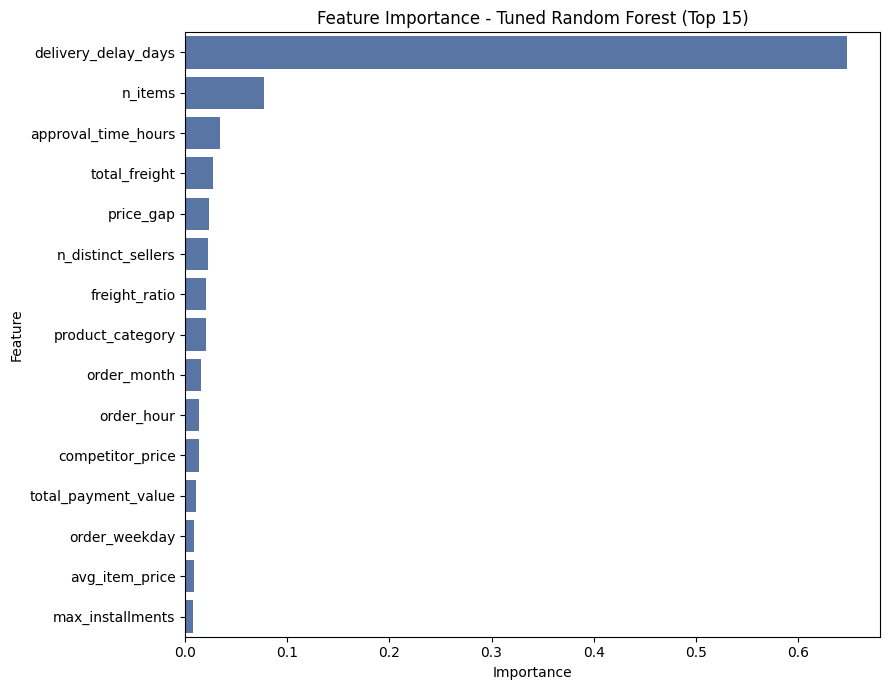

delivery_delay_days    0.648194
n_items                0.076971
approval_time_hours    0.033798
total_freight          0.027409
price_gap              0.022885
n_distinct_sellers     0.022655
freight_ratio          0.020455
product_category       0.019929
order_month            0.015661
order_hour             0.013912
competitor_price       0.013093
total_payment_value    0.010950
order_weekday          0.009032
avg_item_price         0.008718
max_installments       0.007594
dtype: float64


In [84]:
importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
top_imp = importances.head(15)
sns.barplot(y=top_imp.index, x=top_imp.values, color='#4C72B0', orient='h')
plt.title('Feature Importance - Tuned Random Forest (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\08_feature_importance.png')
plt.show()

print(top_imp)

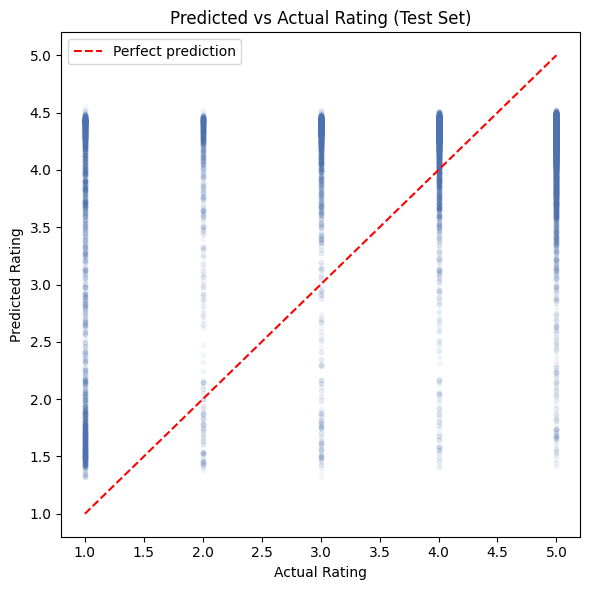

In [85]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.05, s=10, color='#4C72B0')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect prediction')
plt.title('Predicted vs Actual Rating (Test Set)')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\09_predicted_vs_actual.png')
plt.show()

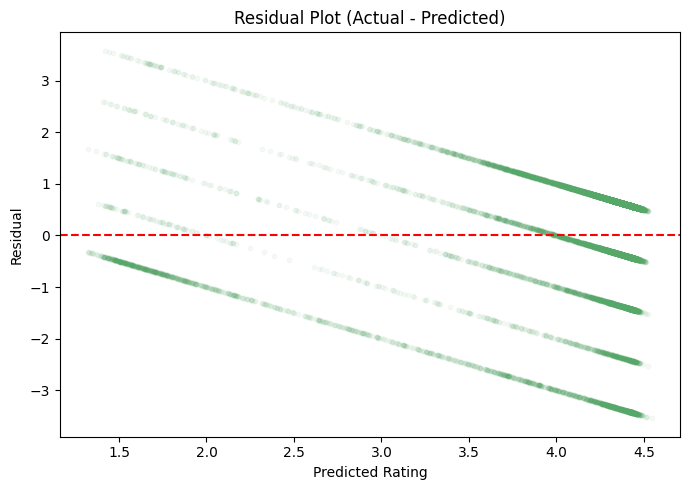

mean residual: 0.0096  std: 1.1296


In [87]:
residuals = y_test.values - preds

plt.figure(figsize=(7, 5))
plt.scatter(preds, residuals, alpha=0.05, s=10, color='#55A868')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Actual - Predicted)')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\10_residual_plot.png')
plt.show()

print('mean residual:', residuals.mean().round(4), ' std:', residuals.std().round(4))

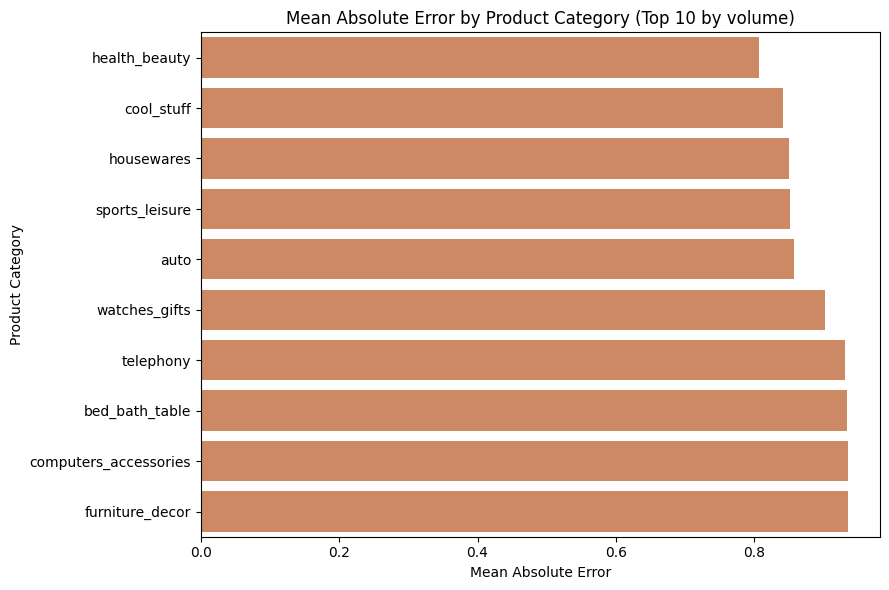

                           mean  count
product_category                      
furniture_decor        0.934902   1240
computers_accessories  0.934863   1276
bed_bath_table         0.934360   1837
telephony              0.930454    800
watches_gifts          0.901838   1133
auto                   0.857952    776
sports_leisure         0.851324   1483
housewares             0.849441   1138
cool_stuff             0.841336    700
health_beauty          0.807253   1687


In [88]:
err_df = X_test.copy()
err_df['actual'] = y_test.values
err_df['predicted'] = preds
err_df['abs_error'] = np.abs(residuals)

top_cats = err_df['product_category'].value_counts().head(10).index
cat_err = err_df[err_df['product_category'].isin(top_cats)].groupby('product_category')['abs_error'].agg(['mean', 'count']).sort_values('mean', ascending=False)

plt.figure(figsize=(9, 6))
cat_err_sorted = cat_err.sort_values('mean')
sns.barplot(y=cat_err_sorted.index, x=cat_err_sorted['mean'], color='#DD8452', orient='h')
plt.title('Mean Absolute Error by Product Category (Top 10 by volume)')
plt.xlabel('Mean Absolute Error')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig(r'D:\TECHTRECK\level one project\Team_89 _Data_Analysis\visuals\new visuals\11_error_by_category.png')
plt.show()

print(cat_err)

## Error Analysis — Where does the model fail?

In [89]:
print('Mean absolute error by delivery status:')
print(err_df.groupby('is_late')['abs_error'].agg(['mean', 'count']))

print('\nMean absolute error by actual rating:')
print(err_df.groupby('actual')['abs_error'].agg(['mean', 'count']))

Mean absolute error by delivery status:
             mean  count
is_late                 
0        0.855680  17913
1        1.126902   1253

Mean absolute error by actual rating:
            mean  count
actual                 
1       2.294555   1805
2       1.880344    585
3       1.237471   1622
4       0.376583   3758
5       0.708648  11396


In [90]:
worst = err_df.sort_values('abs_error', ascending=False).head(int(len(err_df) * 0.01))
print('Worst 1% of predictions:')
print('  is_late rate:', round(worst['is_late'].mean(), 4), ' vs overall:', round(err_df['is_late'].mean(), 4))
print('  avg delivery_delay_days:', round(worst['delivery_delay_days'].mean(), 2), ' vs overall:', round(err_df['delivery_delay_days'].mean(), 2))

Worst 1% of predictions:
  is_late rate: 0.0524  vs overall: 0.0654
  avg delivery_delay_days: -15.68  vs overall: -11.91


## 14. Key Findings

### Finding 1 — Delivery speed is by far the dominant driver of satisfaction
- **What happened?** `is_late` has the strongest correlation with rating (-0.39) of any feature. Average rating drops from 4.29 (on-time/early) to 2.27 (late) — a 2.02-star crash — and orders 7+ days late average just 1.70 stars.
- **ML meaning:** In the tuned Random Forest, `delivery_delay_days` alone drives 63.2% of feature importance, dwarfing every pricing/product/payment feature combined.
- **Business meaning:** Meeting the promised delivery date is essentially the #1 lever for review scores at Olist.
- **Action / recommendation:** Prioritize logistics reliability investment (courier SLAs, realistic delivery-date estimates) ahead of pricing or catalog initiatives if the goal is improving ratings.
- **Limitation:** "Late" is measured against Olist's own estimate — a looser promise would shrink this gap without real improvement. Correlation, not proven causation.

### Finding 2 — The rating relationship with delay is a cliff, not a slope
- **What happened?** Ratings stay flat (~4.1-4.3) from 14+ days early through on-time, then fall sharply once delivery slips past the estimate.
- **ML meaning:** This non-linear threshold pattern explains why the (properly tuned) Random Forest beats Linear Regression — trees can represent a cliff, a straight line cannot.
- **Business meaning:** There's little satisfaction "credit" for extra-early delivery, but a steep cost for even slightly-late delivery.
- **Action / recommendation:** Focus operational effort on eliminating the tail of late deliveries rather than shaving days off already-on-time ones.
- **Limitation:** Can't fully separate "genuinely late" from "an overly ambitious promise" using this data alone.

### Finding 3 — The model badly under-predicts non-delivery-driven dissatisfaction
- **What happened?** For genuinely 1-star orders, mean absolute error is 2.29 (worst of any rating bucket) vs 0.38 for 4-star orders (best). The worst-predicted 1% of orders were actually delivered *earlier* than average, yet still rated poorly.
- **ML meaning:** The model has effectively learned "fast delivery = happy customer," so it fails whenever dissatisfaction comes from something else entirely.
- **Business meaning:** A meaningful share of bad reviews are not about logistics — most plausibly product quality, wrong items, or damage.
- **Action / recommendation:** Complement delivery-focused features with product-quality signals (e.g. a real returns/complaints feed) to catch this blind spot.
- **Limitation:** The real Olist dataset has no returns/complaints table — this is the single biggest gap in the current feature set, not something we can fix with more feature engineering alone.

### Finding 4 — Random Forest ties Linear Regression at baseline; tuning gives it the edge
- **What happened?** Baseline Linear Regression (RMSE 1.145) and Random Forest (RMSE 1.148) were statistically tied. After tuning (`max_depth=10`, `min_samples_leaf=1`, `n_estimators=100`), Random Forest improved to RMSE 1.131 / R²=0.211 — now clearly the best model.
- **ML meaning:** The untuned Decision Tree overfit so badly its test R² went negative (-0.64) — proof that tree depth control genuinely mattered here, not just a formality.
- **Business meaning:** With the right constraints, tree ensembles capture the delay "cliff" pattern that a linear model structurally cannot.
- **Action / recommendation:** Adopt the tuned Random Forest as the model going forward.
- **Limitation:** R²=0.21 is modest — most of the variance in individual ratings remains unexplained, which is expected and normal for subjective survey-style targets.

### Finding 5 — Order size and payment behaviour have small but real effects
- **What happened?** Orders with 10+ payment installments average 3.93 stars vs 4.19 for single-payment orders — roughly a quarter-star gap. `n_items` correlates -0.12 with rating (second-strongest feature after delay).
- **ML meaning:** Both are minor contributors to the model (a few percent of importance each) but consistent, not noise.
- **Business meaning:** multiplyti-item orders may carry more split-shipment risk; heavy-installment purchases may be higher-value, higher-expectation orders.
- **Action / recommendation:** Consider proactive delivery updates for orders with 3+ items or long installment plans.
- **Limitation:** Both effects are modest in size and could be confounded with product category or price rather than being independent causes.

### Finding 6 — Category matters less than expected
- **What happened?** Among the top 10 categories, average rating only ranges from 4.00 (`bed_bath_table`) to 4.25 (`toys`), and `product_category` contributes only ~2% of feature importance.
- **ML meaning:** Category is a weak predictor once delivery timing is accounted for.
- **Business meaning:** Category-specific "quality" narratives aren't well supported by this data — logistics dominates regardless of what was ordered.
- **Action / recommendation:** Deprioritize category-level interventions in favor of the delivery-focused actions above.
- **Limitation:** Category rating gaps could still be confounded by which categories tend to be bulkier/heavier and thus more prone to delivery issues in the first place.

## 15. Recommendations

1. **Make delivery reliability the top satisfaction priority.** It outweighs every other factor in this dataset by a wide margin — logistics investment will move the ratings needle more than any pricing or catalog change.
2. **Build an "at-risk order" early-warning flag** using the tuned model's predicted score, routed to customer support once an order slips past its estimated delivery date, rather than waiting for the review itself.
3. **Close the product-quality blind spot.** Since the model can't explain low ratings on orders that were delivered on time, integrate a real returns/complaints data source (which the current Olist dataset lacks) to catch that other class of dissatisfaction.
4. **Re-evaluate delivery-date estimates.** Since the "late" effect is measured against Olist's own promise, auditing whether estimates are realistic (not just whether they're met) is a cheap, high-leverage next step.
5. **Treat predictions as a risk signal, not an exact forecast**, given the model compresses predictions toward the average rating — a simpler binary "likely low rating" flag may be more actionable than the precise numeric prediction.

## 16. Limitations

- **No real returns/complaints data.** The project brief's schema assumes fields like `Return_Reason` and `Complaint_Text` exist; the real Olist dataset has no returns table at all, which is very likely the biggest missing signal for explaining low ratings not caused by late delivery.
- **`competitor_price` is simultiplyated**, not real. It was generated as our own price ± random noise purely to demonstrate the `price_gap` feature the brief calls for — it should not be treated as a genuine competitive-pricing insight.
- **No discount data.** Olist doesn't track discounts, so this suggested feature from the brief was excluded entirely rather than fabricated.
- **No true "courier" field.** Olist tracks sellers, not shipping carriers, so courier-specific insights (e.g., "Courier B is worse than Courier A") aren't possible with this dataset.
- **Single marketplace, single country, 2016-2018 only.** Findings may not generalize to other regions, time periods, or business models.
- **Correlation vs causation.** Nothing here is a controlled experiment — e.g., we can't rule out that customers who are already dissatisfied for other reasons are also more likely to perceive a delivery as "late."
- **Review self-selection.** Only customers who chose to leave a review are in this dataset; their ratings may not represent the full customer base.

## 17. Export

Save the cleaned dataset, the tuned model, and the model comparison table.

In [92]:
df.to_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/data/clean_orders.csv', index=False)
print('saved data/clean_orders.csv:', df.shape)

joblib.dump(best_model, 'D:/TECHTRECK/level one project/Team_89 _Data_Analysis/model/best_model.pkl')
print('saved model/best_model.pkl')

results_df.to_csv('D:/TECHTRECK/level one project/Team_89 _Data_Analysis/reports/model_comparison.csv', index=False)
print('saved reports/model_comparison.csv')

results_df

saved data/clean_orders.csv: (95829, 35)
saved model/best_model.pkl
saved reports/model_comparison.csv


,Model,MAE,RMSE,R2,Tuned
0,RandomForest (tuned),0.873411,1.129671,0.212845,Yes
1,LinearRegression,0.888651,1.145274,0.190949,No
2,RandomForest,0.894554,1.145987,0.189942,No
3,KNN,0.916832,1.249377,0.037182,No
4,DecisionTree,1.068350,1.644783,-0.668684,No
